# Evaluacion del modelo de churn (5 meses)

Cambios respecto a la version anterior:

- Target ampliado: churn = duracion <= 5 meses (antes <= 3)
- Features solo de meses 1 y 2 (month3 ya cae en la ventana de churn)
- Ratios nuevos: `leads_per_price`, `shows_per_lead`, `calls_per_visit`, `visits_per_price`, `shows_per_price`
- Sin class weighting (29% churn, no hace falta)
- Excluidas `n_months_post_onboarding`, `stable_price_*`, `invoice_post_*` por leakage

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    precision_recall_curve, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay,
)
from sklearn.inspection import permutation_importance

import warnings
warnings.filterwarnings("ignore")

## 1. Datos

In [2]:
df = pd.read_parquet("../data/df_5m_churn.parquet")
target = "churned_5m"

print(f"Dataset: {df.shape[0]} contratos, {df.shape[1]} columnas")
print(f"Churn rate: {df[target].mean():.1%} ({int(df[target].sum())} contratos)")

Dataset: 3599 contratos, 118 columnas
Churn rate: 28.9% (1039 contratos)


## 2. Seleccion de features

Excluimos identificadores, metadata, flags de missing y variables con leakage (`n_months_post_onboarding` es proxy directo de la duracion, `stable_price_*` e `invoice_post_*` usan datos post-onboarding).

In [3]:
meta_cols = [
    "advertiser_zrive_id", "contract_id", "period_int",
    "contract_start_date", "contract_end_period", "contrato_churn_date",
    "contract_duration_months", "advertiser_group_id", "advertiser_province",
    "is_right_censored", "right_censoring_case", "province_id",
]
leakage_cols = [
    "n_months_post_onboarding",
    "stable_price_mean", "stable_price_median", "stable_price_std",
]
exclude = set(meta_cols + leakage_cols + [target])
feature_cols = [
    c for c in df.columns
    if c not in exclude
    and not c.endswith("_was_missing")
    and not c.startswith("invoice_post_")
]

print(f"{len(feature_cols)} features seleccionadas")
print(f"\nFeatures excluidas por leakage: {leakage_cols}")

74 features seleccionadas

Features excluidas por leakage: ['n_months_post_onboarding', 'stable_price_mean', 'stable_price_median', 'stable_price_std']


## 3. Split por advertiser

Todos los contratos del mismo advertiser van al mismo set para evitar leakage por advertiser.

In [4]:
X = df[feature_cols].fillna(0)
y = df[target].astype(int)
groups = df["advertiser_zrive_id"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(f"Train: {len(X_train)} ({y_train.mean():.1%} churn)")
print(f"Test:  {len(X_test)} ({y_test.mean():.1%} churn)")
print(f"Advertisers train: {groups.iloc[train_idx].nunique()}, test: {groups.iloc[test_idx].nunique()}")
print(f"Overlap: {len(set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]))}")

Train: 2874 (29.0% churn)
Test:  725 (28.3% churn)
Advertisers train: 2780, test: 696
Overlap: 0


## 4. Comparativa de modelos (train vs test)

Probamos 4 modelos sin class weighting. Logistic Regression con regularizacion (C=0.1), Random Forest con 20 arboles (suficiente segun las learning curves anteriores), y Gradient Boosting.

In [5]:
models = {
    "Baseline": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(max_iter=1000, C=0.1, random_state=42)),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=20, random_state=42, n_jobs=-1,
    ),
    "Gradient Boosting": HistGradientBoostingClassifier(
        max_iter=200, max_depth=5, learning_rate=0.1, random_state=42,
    ),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_proba_tr = model.predict_proba(X_train)[:, 1]
    y_proba_te = model.predict_proba(X_test)[:, 1]
    
    tr_auc = roc_auc_score(y_train, y_proba_tr)
    te_auc = roc_auc_score(y_test, y_proba_te)
    te_pr = average_precision_score(y_test, y_proba_te)
    
    results.append({
        "name": name, "model": model,
        "train_auc": tr_auc, "test_auc": te_auc,
        "pr_auc": te_pr, "y_proba": y_proba_te,
        "y_pred": model.predict(X_test),
    })

print(f"{'Modelo':<25} {'Train AUC':>10} {'Test AUC':>10} {'Gap':>8} {'PR-AUC':>8}")
print("-" * 65)
for r in results:
    gap = r["train_auc"] - r["test_auc"]
    print(f"{r['name']:<25} {r['train_auc']:>10.3f} {r['test_auc']:>10.3f} {gap:>+8.3f} {r['pr_auc']:>8.3f}")

Modelo                     Train AUC   Test AUC      Gap   PR-AUC
-----------------------------------------------------------------
Baseline                       0.500      0.500   +0.000    0.283
Logistic Regression            0.684      0.674   +0.010    0.437
Random Forest                  0.999      0.667   +0.332    0.429
Gradient Boosting              0.996      0.671   +0.325    0.435


## 5. Reduccion de overfitting

Los arboles overfittean mucho (train ~1.0, test ~0.67). Probamos feature selection (top 15) y reducir max_depth a 3.

In [6]:
# Ranking de features con el GB de 74 features
gb_full = [r for r in results if "Gradient" in r["name"]][0]["model"]
perm_imp = permutation_importance(
    gb_full, X_test, y_test,
    n_repeats=10, random_state=42, scoring="roc_auc",
)
feat_ranking = pd.Series(
    perm_imp.importances_mean, index=feature_cols
).sort_values(ascending=False)

top15 = list(feat_ranking.head(15).index)
print("Top 15 features:")
for i, (feat, imp) in enumerate(feat_ranking.head(15).items(), 1):
    print(f"  {i:>2}. {feat:<40} {imp:.4f}")

Top 15 features:
   1. has_group                                0.0280
   2. monthly_published_ads_month2             0.0239
   3. monthly_distinct_ads_month1              0.0199
   4. usage_ratio                              0.0192
   5. monthly_total_invoice                    0.0187
   6. monthly_total_invoice_trend              0.0086
   7. monthly_visits_month2                    0.0061
   8. leads_per_price                          0.0059
   9. monthly_destacados_ads                   0.0051
  10. monthly_distinct_ads_month2              0.0049
  11. monthly_avg_ad_price_month1              0.0044
  12. monthly_distinct_ads_std                 0.0042
  13. monthly_shows_month1                     0.0041
  14. monthly_total_invoice_month1             0.0039
  15. monthly_avg_ad_price                     0.0037


In [7]:
# Comparativa: todas las features vs top 15, depth 5 vs 3
configs = {
    "74 feat, depth=5": (feature_cols, 5),
    "74 feat, depth=3": (feature_cols, 3),
    "Top 15, depth=5": (top15, 5),
    "Top 15, depth=3": (top15, 3),
}

gkf = GroupKFold(n_splits=5)

print(f"{'Config':<25} {'Train':>7} {'Test':>7} {'Gap':>7} {'CV AUC':>14}")
print("-" * 65)
for label, (cols, depth) in configs.items():
    Xc = df[cols].fillna(0)
    Xc_tr, Xc_te = Xc.iloc[train_idx], Xc.iloc[test_idx]
    
    gb = HistGradientBoostingClassifier(
        max_iter=200, max_depth=depth, learning_rate=0.1, random_state=42,
    )
    gb.fit(Xc_tr, y_train)
    
    tr = roc_auc_score(y_train, gb.predict_proba(Xc_tr)[:, 1])
    te = roc_auc_score(y_test, gb.predict_proba(Xc_te)[:, 1])
    
    cv = cross_val_score(
        HistGradientBoostingClassifier(max_iter=200, max_depth=depth, learning_rate=0.1, random_state=42),
        Xc_tr, y_train, cv=gkf, groups=groups.iloc[train_idx], scoring="roc_auc", n_jobs=-1,
    )
    print(f"{label:<25} {tr:>7.3f} {te:>7.3f} {tr-te:>+7.3f} {cv.mean():.3f}±{cv.std():.3f}")

Config                      Train    Test     Gap         CV AUC
-----------------------------------------------------------------


74 feat, depth=5            0.996   0.671  +0.325 0.686±0.039


74 feat, depth=3            0.936   0.689  +0.247 0.691±0.026


Top 15, depth=5             0.978   0.699  +0.279 0.670±0.018


Top 15, depth=3             0.883   0.701  +0.182 0.677±0.018


## 6. Modelo final: GB top 15 features, depth=3

Gap baja de +0.33 a +0.18 y el test AUC sube de 0.671 a 0.701.

In [8]:
X_train_15 = df[top15].fillna(0).iloc[train_idx]
X_test_15 = df[top15].fillna(0).iloc[test_idx]

gb_final = HistGradientBoostingClassifier(
    max_iter=200, max_depth=3, learning_rate=0.1, random_state=42,
)
gb_final.fit(X_train_15, y_train)

y_proba_final = gb_final.predict_proba(X_test_15)[:, 1]
y_proba_train_final = gb_final.predict_proba(X_train_15)[:, 1]

print(f"Train AUC: {roc_auc_score(y_train, y_proba_train_final):.3f}")
print(f"Test AUC:  {roc_auc_score(y_test, y_proba_final):.3f}")
print(f"Test PR-AUC: {average_precision_score(y_test, y_proba_final):.3f}")

Train AUC: 0.883
Test AUC:  0.701
Test PR-AUC: 0.487


## 7. Cross-validation

In [9]:
gkf = GroupKFold(n_splits=5)

roc_cv = cross_val_score(
    HistGradientBoostingClassifier(max_iter=200, max_depth=3, learning_rate=0.1, random_state=42),
    X_train_15, y_train, cv=gkf, groups=groups.iloc[train_idx],
    scoring="roc_auc", n_jobs=-1,
)
pr_cv = cross_val_score(
    HistGradientBoostingClassifier(max_iter=200, max_depth=3, learning_rate=0.1, random_state=42),
    X_train_15, y_train, cv=gkf, groups=groups.iloc[train_idx],
    scoring="average_precision", n_jobs=-1,
)

print(f"ROC AUC (CV): {roc_cv.mean():.3f} ± {roc_cv.std():.3f}")
print(f"PR AUC (CV):  {pr_cv.mean():.3f} ± {pr_cv.std():.3f}")
print(f"\nFolds: {[f'{s:.3f}' for s in roc_cv]}")

ROC AUC (CV): 0.677 ± 0.018
PR AUC (CV):  0.451 ± 0.023

Folds: ['0.655', '0.670', '0.664', '0.691', '0.704']


## 8. Curvas ROC y Precision-Recall

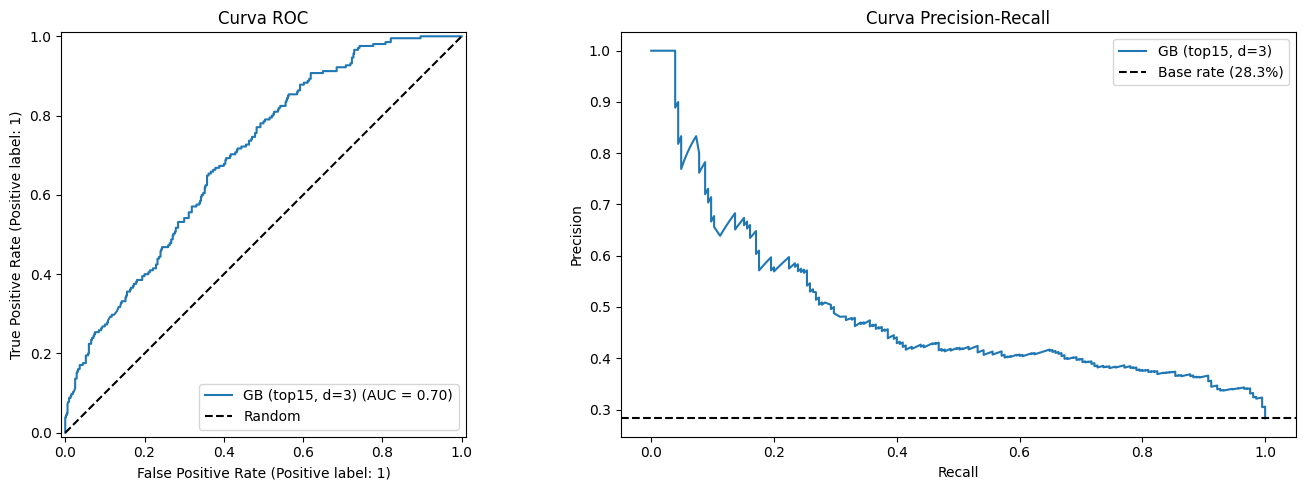

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
RocCurveDisplay.from_predictions(y_test, y_proba_final, name="GB (top15, d=3)", ax=axes[0])
axes[0].plot([0, 1], [0, 1], "k--", label="Random")
axes[0].set_title("Curva ROC")
axes[0].legend()

# Precision-Recall
precisions, recalls, _ = precision_recall_curve(y_test, y_proba_final)
axes[1].plot(recalls, precisions, label="GB (top15, d=3)")
axes[1].axhline(y=y_test.mean(), color="k", linestyle="--", label=f"Base rate ({y_test.mean():.1%})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Curva Precision-Recall")
axes[1].legend()

plt.tight_layout()
plt.show()

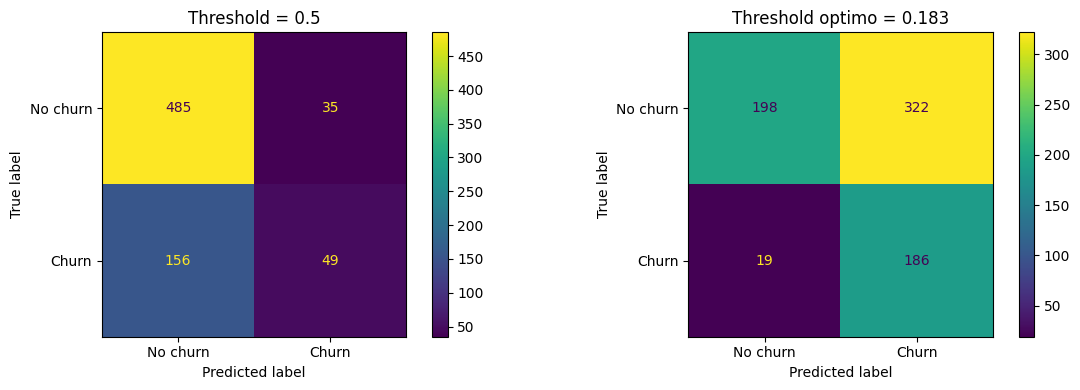

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Con threshold 0.5
ConfusionMatrixDisplay.from_predictions(
    y_test, (y_proba_final >= 0.5).astype(int),
    display_labels=["No churn", "Churn"], ax=axes[0],
)
axes[0].set_title("Threshold = 0.5")

# Con threshold optimo (ver siguiente seccion)
precisions_t, recalls_t, thresholds_t = precision_recall_curve(y_test, y_proba_final)
f1_scores = 2 * (precisions_t * recalls_t) / (precisions_t + recalls_t + 1e-8)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds_t[best_idx] if best_idx < len(thresholds_t) else 1.0

ConfusionMatrixDisplay.from_predictions(
    y_test, (y_proba_final >= best_thresh).astype(int),
    display_labels=["No churn", "Churn"], ax=axes[1],
)
axes[1].set_title(f"Threshold optimo = {best_thresh:.3f}")

plt.tight_layout()
plt.show()

## 9. Feature importance

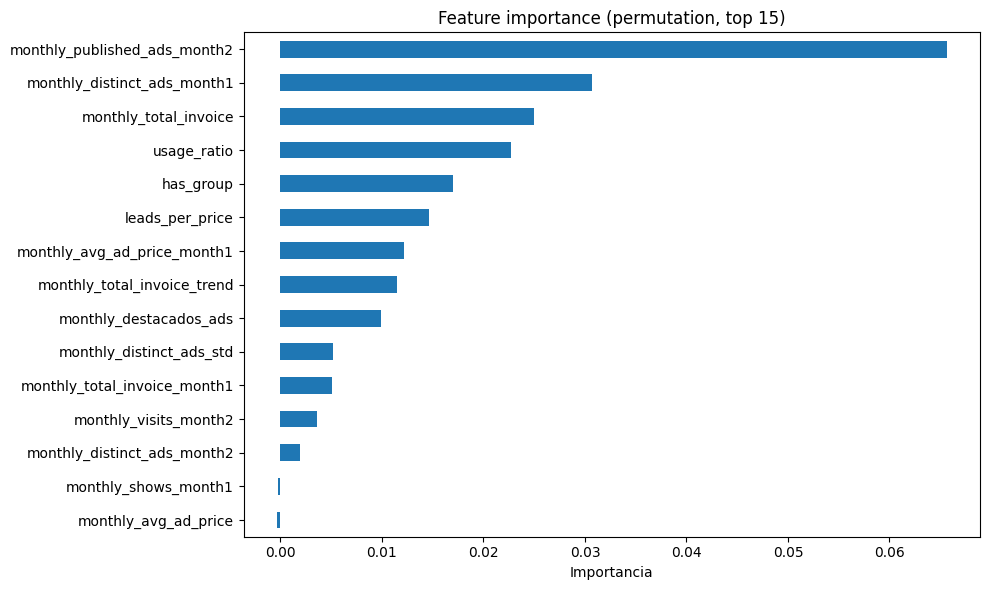

In [12]:
perm_imp_final = permutation_importance(
    gb_final, X_test_15, y_test,
    n_repeats=10, random_state=42, scoring="roc_auc",
)
imp_series = pd.Series(
    perm_imp_final.importances_mean, index=top15,
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
imp_series.plot(kind="barh", ax=ax)
ax.set_title("Feature importance (permutation, top 15)")
ax.set_xlabel("Importancia")
plt.tight_layout()
plt.show()

## 10. Threshold optimo

In [13]:
print(f"Threshold optimo (max F1): {best_thresh:.3f}")
print(f"Precision: {precisions_t[best_idx]:.3f}")
print(f"Recall:    {recalls_t[best_idx]:.3f}")
print(f"F1:        {f1_scores[best_idx]:.3f}")

print(f"\nClassification report (threshold={best_thresh:.3f}):")
y_pred_opt = (y_proba_final >= best_thresh).astype(int)
print(classification_report(y_test, y_pred_opt, target_names=["No churn", "Churn"]))

Threshold optimo (max F1): 0.183
Precision: 0.366
Recall:    0.907
F1:        0.522

Classification report (threshold=0.183):
              precision    recall  f1-score   support

    No churn       0.91      0.38      0.54       520
       Churn       0.37      0.91      0.52       205

    accuracy                           0.53       725
   macro avg       0.64      0.64      0.53       725
weighted avg       0.76      0.53      0.53       725



## 11. Perfiles de riesgo

In [14]:
df_test = X_test_15.copy()
df_test["churn_proba"] = y_proba_final
df_test["churned"] = y_test.values
df_test["riesgo"] = pd.cut(
    df_test["churn_proba"],
    bins=[0, 0.15, 0.4, 1.0],
    labels=["Bajo", "Medio", "Alto"],
)

profiles = []
for riesgo in ["Bajo", "Medio", "Alto"]:
    mask = df_test["riesgo"] == riesgo
    n = int(mask.sum())
    if n > 0:
        profiles.append({
            "Riesgo": riesgo,
            "N contratos": n,
            "Churn real": f"{df_test.loc[mask, 'churned'].mean():.1%}",
            "Proba media": f"{df_test.loc[mask, 'churn_proba'].mean():.3f}",
        })

pd.DataFrame(profiles)

,Riesgo,N contratos,Churn real,Proba media
0,Bajo,183,9.8%,0.061
1,Medio,352,29.8%,0.278
2,Alto,190,43.2%,0.516


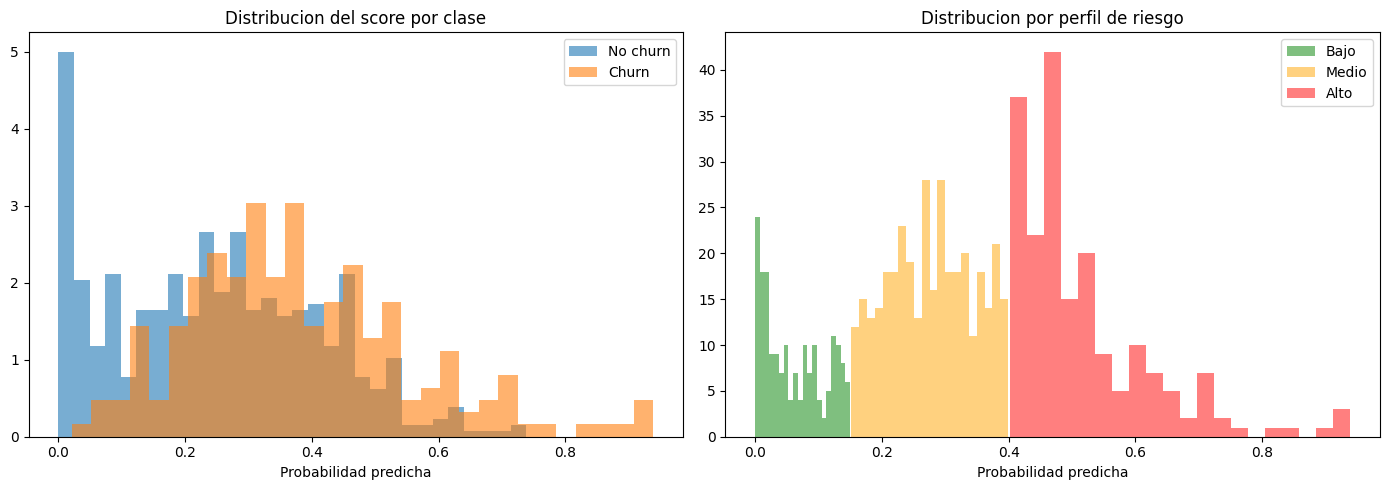

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(y_proba_final[y_test == 0], bins=30, alpha=0.6, label="No churn", density=True)
axes[0].hist(y_proba_final[y_test == 1], bins=30, alpha=0.6, label="Churn", density=True)
axes[0].set_xlabel("Probabilidad predicha")
axes[0].set_title("Distribucion del score por clase")
axes[0].legend()

for riesgo, color in [("Bajo", "green"), ("Medio", "orange"), ("Alto", "red")]:
    mask = df_test["riesgo"] == riesgo
    if mask.sum() > 0:
        axes[1].hist(
            df_test.loc[mask, "churn_proba"], bins=20,
            alpha=0.5, label=riesgo, color=color,
        )
axes[1].set_xlabel("Probabilidad predicha")
axes[1].set_title("Distribucion por perfil de riesgo")
axes[1].legend()

plt.tight_layout()
plt.show()

## 12. Metrica de negocio

Si intervenimos el top K% de clientes con mayor probabilidad de churn, cuantos churns capturamos?

In [16]:
sorted_idx = np.argsort(-y_proba_final)
total_churns = y_test.sum()

rows = []
for k in [5, 10, 20, 30]:
    n_int = int(len(y_test) * k / 100)
    top_idx = sorted_idx[:n_int]
    tp = y_test.iloc[top_idx].sum()
    rows.append({
        "Top %": f"{k}%",
        "Intervenidos": n_int,
        "Churns capturados": int(tp),
        "Precision": f"{tp/n_int:.1%}",
        "Recall": f"{tp/total_churns:.1%}",
    })

pd.DataFrame(rows)

,Top %,Intervenidos,Churns capturados,Precision,Recall
0,5%,36,23,63.9%,11.2%
1,10%,72,41,56.9%,20.0%
2,20%,145,68,46.9%,33.2%
3,30%,217,92,42.4%,44.9%


## 13. Comparativa con modelo anterior (churned_3m)

| | Anterior (3m) | Actual (5m) |
|---|---|---|
| Churn rate | 6.2% | 28.9% |
| CV ROC AUC | ~0.77 | 0.677 |
| CV PR AUC | ~0.21 | ~0.46 |
| Gap (overfitting) | +0.15 | +0.18 |
| Features | 3 meses | 2 meses |

ROC AUC baja porque usamos menos datos y predecimos mas lejos. PR-AUC sube porque hay mas positivos.

## Conclusiones

- El target a 5 meses es mas realista y elimina el desbalanceo (6% → 29%).
- Solo features de meses 1-2, sin leakage de variables post-onboarding.
- CV ROC AUC ~0.68 con top 15 features y depth=3. Gap de +0.18.
- `has_group`, anuncios publicados y usage_ratio son las variables que mas pesan.
- `leads_per_price` (ratio nuevo) entra en el top 8.